# Analyze and make a table


天体一覧の上位20天体
各天体について、
SED ecsvファイルの解析をする




## Utility
### - 天体名対応辞書作成

In [1]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 2300
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit')
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map]
  sources_blazars2 = sources2[element_map]
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  
  
  sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_cls_converted = str(sources_blazars_cls).strip()

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### 使い方

In [2]:
dict_sourcename = get_dict_sourcenames()
dict_sourcename[0:2]

4FGL name,assoc name,CLASS,index
str18,str28,str5,int64
4fgl_j2253.9+1609,3c_454.3,FSRQ,1
4fgl_j1104.4+3812,mkn_421,BLL,2


In [3]:
dict_sourcename[0]['assoc name']  = '3C454.3' 
dict_sourcename[1]['assoc name']  = 'Mrk421' 
dict_sourcename[2]['assoc name']  = 'BLLac' 
dict_sourcename[3]['assoc name']  = 'CTA102' 
dict_sourcename[4]['assoc name']  = '3C279'
dict_sourcename[5]['assoc name']  = 'S50716+71' 
dict_sourcename[6]['assoc name']  = 'PKS1424-41' 
dict_sourcename[7]['assoc name']  = 'PKS0426-380'
dict_sourcename[8]['assoc name']  = 'PKS0537-441'
dict_sourcename[9]['assoc name']  = 'PKS2155-304'
dict_sourcename[10]['assoc name'] = 'PKS0454-234'
dict_sourcename[11]['assoc name'] = 'PKS1510-089'
dict_sourcename[12]['assoc name'] = 'PKS1502+106'
dict_sourcename[13]['assoc name'] = 'TON599'
dict_sourcename[14]['assoc name'] = 'PKS0346-27'
dict_sourcename[15]['assoc name'] = '4c+01.02'
dict_sourcename[16]['assoc name'] = '4c+55.17'
dict_sourcename[17]['assoc name'] = '4c+21.35'
dict_sourcename[18]['assoc name'] = 'PKS1830-211'
dict_sourcename[19]['assoc name'] = 'PKS0208-512'
dict_sourcename[0:15]

4FGL name,assoc name,CLASS,index
str18,str28,str5,int64
4fgl_j2253.9+1609,3C454.3,FSRQ,1
4fgl_j1104.4+3812,Mrk421,BLL,2
4fgl_j2202.7+4216,BLLac,BLL,3
4fgl_j2232.6+1143,CTA102,FSRQ,4
4fgl_j1256.1-0547,3C279,FSRQ,5
4fgl_j0721.9+7120,S50716+71,BLL,6
4fgl_j1427.9-4206,PKS1424-41,FSRQ,7
4fgl_j0428.6-3756,PKS0426-380,bll,8
4fgl_j0538.8-4405,PKS0537-441,BLL,9



## - Utility functions


### Probability table generation

14 bins from 9 to 22


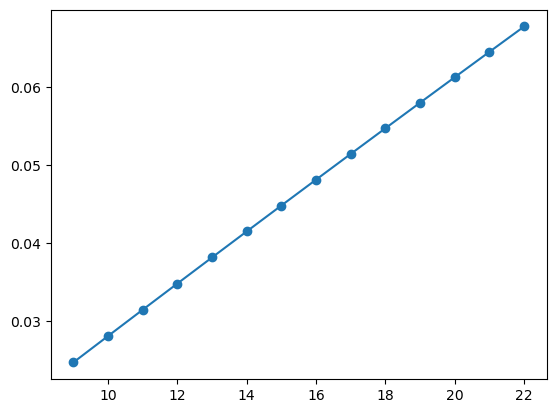

In [4]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')

### Peak detection
### Gaussian
### Red.Chisq. calculation
### plotSED

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit


###################
# Peak detection
###################
nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1.0):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

###################
# Utility functions
###################
def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)

def plotSED(x, y, yerr, fitted_line, peakbininit, nconsecutive, residuals,reduced_chi_squared, obsdate, idx, sourcename="",sourcenameheader=""):
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, fitted_line(x), '-', label='Fitted Line')
  plt.plot(x[peakbininit:peakbininit+nconsecutive],
           y[peakbininit:peakbininit+nconsecutive], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [MeV]')
  plt.ylabel(r"E$^2d\phi/d$E [MeV/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [MeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_sedwithpeak_{idx}.png", dpi=300, bbox_inches='tight')

def plotSED_erg_GeV(x, y, yerr, fitted_line, peakbininit, nconsecutive, residuals,reduced_chi_squared, obsdate, idx, sourcename='',sourcenameheader=''):
  
  y_scalefactor= (y.to(u.Unit("erg cm-2 s-1")).value/y.value)[0]
  model_y = fitted_line(x) * y_scalefactor
  
  x = x.to(u.GeV).value  
  y = y.to(u.Unit("erg cm-2 s-1")).value
  yerr = yerr.to(u.Unit("erg cm-2 s-1")).value
  
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', label='Fitted Line')
  # plt.plot(x[peakbininit:peakbininit+nconsecutive],
  #          y[peakbininit:peakbininit+nconsecutive], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_sedwithpeak_{idx}.png", dpi=300, bbox_inches='tight')

###################
# Main function
###################
def eval_spectra(filepath,suffix=''): #'data/3C454.3_allsed_14d_min11.ecsv'

  sourcenameheader = ''
  if suffix != '':
    sourcenameheader = suffix + '_'
  sourcename = filepath.split('_')[0]
  sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  array_chisq = []
  t_residual = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    
    ### fit the data with the fitter ###
    # logpar_init.amplitude.value=x[1]*1.0e-8
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    residuals = (y-fitted_line(x))/yerr
    # print(fit.fit_info)
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    array_chisq.append(reduced_chi_squared)

    peakbininit = get_consecutive_bins(residuals,nconsecutive)
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)
    t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)], names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    t_residual = vstack([t_residual,t_residual_ind])
    if peakbininit > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += 1
      plotSED_erg_GeV(x, y , yerr, fitted_line, peakbininit, nconsecutive, residuals, reduced_chi_squared, obsdate, idx, sourcename, sourcenameheader)


  ### bin数分布 ###
  fig = plt.figure(figsize=(8, 5))
  hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), histtype='step', lw=2)
  plt.xlabel('Number of effective bins')
  plt.ylabel('Number of SEDs')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_nbins.png", dpi=300, bbox_inches='tight')

  ### 各Eの residual 分布 ###
  fig = plt.figure(figsize=(8, 5))
  plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  plt.xscale('log')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_residuals.png", dpi=300, bbox_inches='tight')

  
  ### residual 分布 ###
  fig = plt.figure(figsize=(8, 5))
  # plt.hist(t_residual['residual'], bins = 30)
  # plt.yscale('log')  
  # plt.show()
  n, bins, patches =plt.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  # plt.show()

  # Fit a gaussian distribution to the data:
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, len(bins)-1)
  y = n
  popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # popt, pcov = curve_fit(gaussian, x, y)

  plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
  ymin, ymax = plt.ylim()
  plt.ylim(0.8,ymax)
  print('amplitude', popt[0])
  print('mu', popt[1])
  print('sigma', popt[2])
  plt.yscale('log')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_residuals_hist.png", dpi=300, bbox_inches='tight')

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()

  print('Source name:', sourcename)
  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))
  return sourcename, n_detected_peaks, len(array_nbins), len(obsdates), np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins)

In [ ]:
# dict_sourcename = get_dict_sourcenames()
n_brightest_sources = 20

array_data=[]

for sourceinfo in dict_sourcename[0:n_brightest_sources]:
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_14d_min11.ecsv'
  sourcename, n_detected_peaks, n_used_seds, n_used_seds_orig, prob_peaked_sed = eval_spectra(filepath) 
  ratio = n_detected_peaks / n_used_seds_orig
  array_data.append((sourceinfo['assoc name'], sourceinfo['4FGL name'], n_detected_peaks, n_used_seds_orig, ratio, prob_peaked_sed))

headers = ['Source name', '4FGL name', 'N detected peaks', 'N used SEDs','Ratio','Prediction']

textabular = f"l|{'r'*len(headers)}"
texheader = " & ".join(headers) + "\\\\"
texdata = "\\hline\n"
for data in array_data:
    # print(data)
    # texdata += f"{data[0]} & {data[1]} & {data[2]} & {data[3]} & {data[4]} \\\\\n"
    texdata += f"{data[0]} & {data[1]} & {data[2]} & {data[3]} & {data[4]:.3f} & {data[5]:.3f} \\\\\n"

print("\\begin{tabular}{"+textabular+"}")
print(texheader)
print(texdata,end="")
print("\\end{tabular}")



